# Radar Chart

This script creates a single test radar chart and a quadrant of four radar charts by specified LEIE excluded NPIs. This is currently a test script for the plot visual and the means of the fraud scoring and the individual risk factors themselves should be updated. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_rows", None)        # show all rows
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.expand_frame_repr", False)  # keep wide frames on one line

In [3]:
unified_dataset = pd.read_csv("/dsa/groups/casestudycf25/team02/unified_dataset.csv")

/tmp/ipykernel_3153/1752534236.py:1: DtypeWarning: Columns (161) have mixed types. Specify dtype option on import or set low_memory=False.
  unified_dataset = pd.read_csv("/dsa/groups/casestudycf25/team02/unified_dataset.csv")


In [4]:
print(unified_dataset.describe().T)

                                                       count          mean           std           min           25%           50%           75%           max
npi                                                 873538.0  1.499586e+09  2.879622e+08  1.003000e+09  1.245797e+09  1.497915e+09  1.750042e+09  1.993000e+09
year                                                873538.0  2.022003e+03  8.169440e-01  2.021000e+03  2.021000e+03  2.022000e+03  2.023000e+03  2.023000e+03
target                                              873538.0  2.335331e-04  1.528001e-02  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00
avg_suplr_sbmtd_chrg_mean                           873538.0  2.659965e+02  5.979047e+02  1.118182e-02  6.666667e+01  1.423830e+02  2.613200e+02  3.862500e+04
avg_suplr_mdcr_alowd_amt_mean                       873538.0  1.016244e+02  3.489268e+02  9.000000e-03  1.943000e+01  5.066872e+01  8.457000e+01  1.528944e+04
avg_suplr_mdcr_pymt_amt_mean                  

In [5]:
unified_dataset.head(3)

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,avg_suplr_sbmtd_chrg_std,avg_suplr_mdcr_alowd_amt_std,avg_suplr_mdcr_pymt_amt_std,avg_suplr_mdcr_stdzd_amt_std,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_std,tot_suplr_benes_std,tot_suplr_clms_std,tot_suplr_srvcs_std,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,covered_recipient_npi,program_year,n_manufacturing_entities,first_payment_date,last_payment_date,total_payment,mean_payment_manufacturers,n_records,charity_indicator,third_party_equals_covered_recipient_indicator,dispute_status_for_publication,number_of_payments_included_in_total_amount,covered_biological,covered_device,covered_drug,covered_medical supply,non-covered_device,non-covered_drug,non-covered_medical supply,n_cities,n_states,n_countries,form_count_cash_or_cash_equivalent,form_count_dividend_profit_or_other_return_on_investment,form_count_in_kind_items_and_services,form_count_stock,form_count_stock_option,form_count_stock_stock_option_or_any_other_ownership_interest,form_sum_cash_or_cash_equivalent,form_sum_dividend_profit_or_other_return_on_investment,form_sum_in_kind_items_and_services,form_sum_stock,form_sum_stock_option,form_sum_stock_stock_option_or_any_other_ownership_interest,third_party_recipient_count_entity,third_party_recipient_count_individual,third_party_recipient_count_no_third_party_payment,third_party_recipient_sum_entity,third_party_recipient_sum_individual,third_party_recipient_sum_no_third_party_payment,nature_count_acquisition,nature_count_charity,nature_count_consulting,nature_count_debt_forgiveness,nature_count_education,nature_count_entertainment,nature_count_faculty_or_speaker,nature_count_food_and_beverage,nature_count_other_services,nature_count_ownership_or_investment,nature_sum_acquisition,nature_sum_charity,nature_sum_consulting,nature_sum_debt_forgiveness,nature_sum_education,nature_sum_entertainment,nature_sum_faculty_or_speaker,nature_sum_food_and_beverage,nature_sum_other_services,nature_sum_ownership_or_investment,n_third_party_entities,total_invested_usd,total_value_of_interest,n_owner_records,immediate_family_member,physician_covered_recipient,y

In [6]:
# Example provider
selected_npi = 1801811096
df_provider = unified_dataset[unified_dataset["npi"] == selected_npi].copy()
df_provider = df_provider.fillna(0)

/tmp/ipykernel_3153/3024824550.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_provider = df_provider.fillna(0)


In [7]:
df_provider

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,avg_suplr_sbmtd_chrg_std,avg_suplr_mdcr_alowd_amt_std,avg_suplr_mdcr_pymt_amt_std,avg_suplr_mdcr_stdzd_amt_std,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_std,tot_suplr_benes_std,tot_suplr_clms_std,tot_suplr_srvcs_std,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,covered_recipient_npi,program_year,n_manufacturing_entities,first_payment_date,last_payment_date,total_payment,mean_payment_manufacturers,n_records,charity_indicator,third_party_equals_covered_recipient_indicator,dispute_status_for_publication,number_of_payments_included_in_total_amount,covered_biological,covered_device,covered_drug,covered_medical supply,non-covered_device,non-covered_drug,non-covered_medical supply,n_cities,n_states,n_countries,form_count_cash_or_cash_equivalent,form_count_dividend_profit_or_other_return_on_investment,form_count_in_kind_items_and_services,form_count_stock,form_count_stock_option,form_count_stock_stock_option_or_any_other_ownership_interest,form_sum_cash_or_cash_equivalent,form_sum_dividend_profit_or_other_return_on_investment,form_sum_in_kind_items_and_services,form_sum_stock,form_sum_stock_option,form_sum_stock_stock_option_or_any_other_ownership_interest,third_party_recipient_count_entity,third_party_recipient_count_individual,third_party_recipient_count_no_third_party_payment,third_party_recipient_sum_entity,third_party_recipient_sum_individual,third_party_recipient_sum_no_third_party_payment,nature_count_acquisition,nature_count_charity,nature_count_consulting,nature_count_debt_forgiveness,nature_count_education,nature_count_entertainment,nature_count_faculty_or_speaker,nature_count_food_and_beverage,nature_count_other_services,nature_count_ownership_or_investment,nature_sum_acquisition,nature_sum_charity,nature_sum_consulting,nature_sum_debt_forgiveness,nature_sum_education,nature_sum_entertainment,nature_sum_faculty_or_speaker,nature_sum_food_and_beverage,nature_sum_other_services,nature_sum_ownership_or_investment,n_third_party_entities,total_invested_usd,total_value_of_interest,n_owner_records,immediate_family_member,physician_covered_recipient,y

In [8]:
unified_dataset["anomaly_score"] = np.random.normal(loc=0.0, scale=1.0, size=len(unified_dataset))

In [9]:
# Define feature domains
risk_factors = {
    "DEMOGRAPHIC RISK":[c for c in df_provider.columns if c.startswith("bene_")],  # Placeholder feature
    "SERVICES RISK": [c for c in df_provider.columns if c.startswith("tot_suplr_")], # placeholder
    "BILLING RISK": ["avg_suplr_sbmtd_chrg_mean", "avg_suplr_mdcr_pymt_amt_median"], # placeholder
    "MANUFACTURER PAYMENTS": ["total_payment", "mean_payment_manufacturers", "n_records", "total_invested_usd"],
    "ENSEMBLE ANOMALY SCORE": ["anomaly_score"]  # Placeholder anomaly score using random 0-1
}

In [10]:
# Compute raw scores for each domain
risk_scores = {}
for domain, cols in risk_factors.items():
    valid_cols = [c for c in cols if c in df_provider.columns]
    if valid_cols:
        risk_scores[domain] = df_provider[valid_cols].mean().mean() # Compute average score
    else:
        risk_scores[domain] = 0 # Default score for missing data

score_df = pd.DataFrame({
    "RiskFactor": risk_scores.keys(),
    "RawScore": risk_scores.values()
})

In [11]:
# Convert raw scores → Z-scores
z_scores = (score_df["RawScore"] - score_df["RawScore"].mean()) / (score_df["RawScore"].std() + 1e-9) # Compute z scores
score_df["ZScore"] = z_scores # Store z scores

# Close radar loop
angles = np.linspace(0, 2*np.pi, len(score_df), endpoint=False) # Create angle positions
angles = np.concatenate((angles, [angles[0]])) # Close radar loop

values = np.concatenate((score_df["ZScore"].values, [score_df["ZScore"].values[0]]))

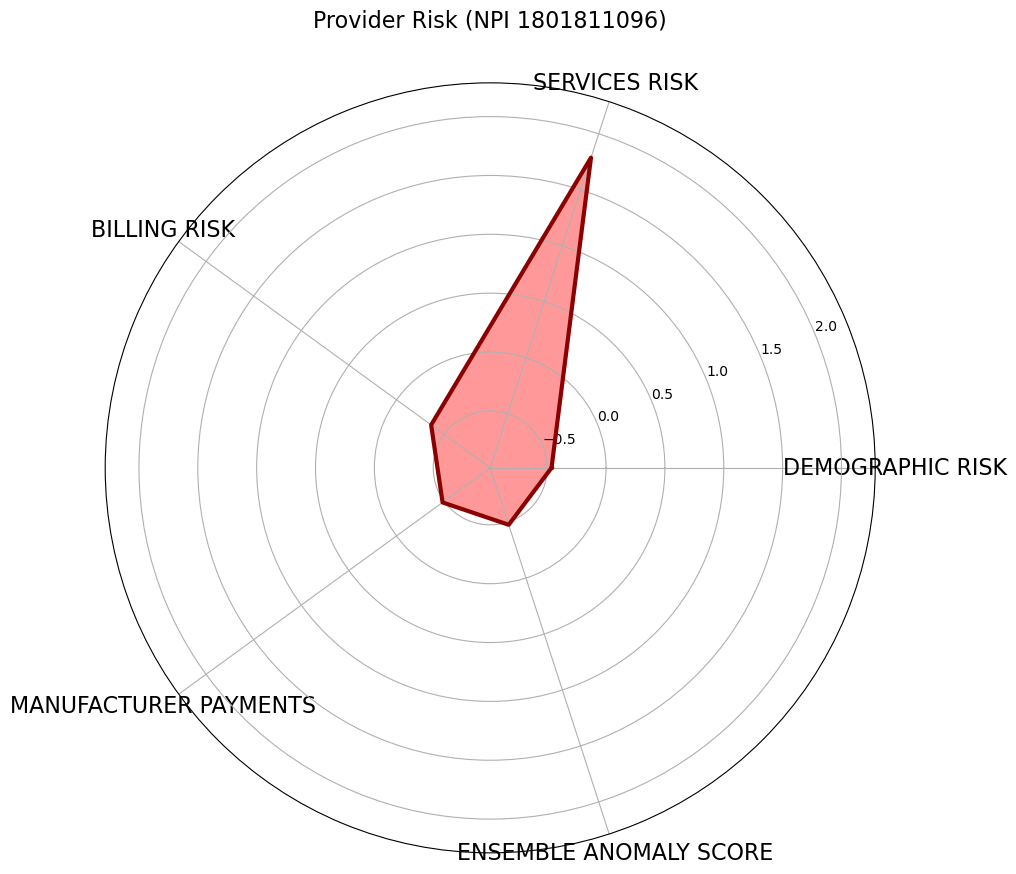

In [14]:
# Plot Radar Chart
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Plot radar
ax.plot(angles, values, linewidth = 3, color = "darkred")
ax.fill(angles, values, alpha = 0.4, color = "red")

# Set category labels
ax.set_xticks(angles[:-1]) # Set tick positions
ax.set_xticklabels(score_df["RiskFactor"], fontsize = 16)

# Set radial limits
ax.set_ylim(values.min() - 0.5, values.max() + 0.5)

ax.set_title(f"Provider Risk (NPI {selected_npi})", fontsize = 16, pad = 40)

plt.show()

/tmp/ipykernel_3153/1860243577.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_provider = unified_dataset[unified_dataset["npi"] == npi_value].fillna(0)  # Filter provider and replace nulls
/tmp/ipykernel_3153/1860243577.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_provider = unified_dataset[unified_dataset["npi"] == npi_value].fillna(0)  # Filter provider and replace nulls
/tmp/ipykernel_3153/1860243577.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. C

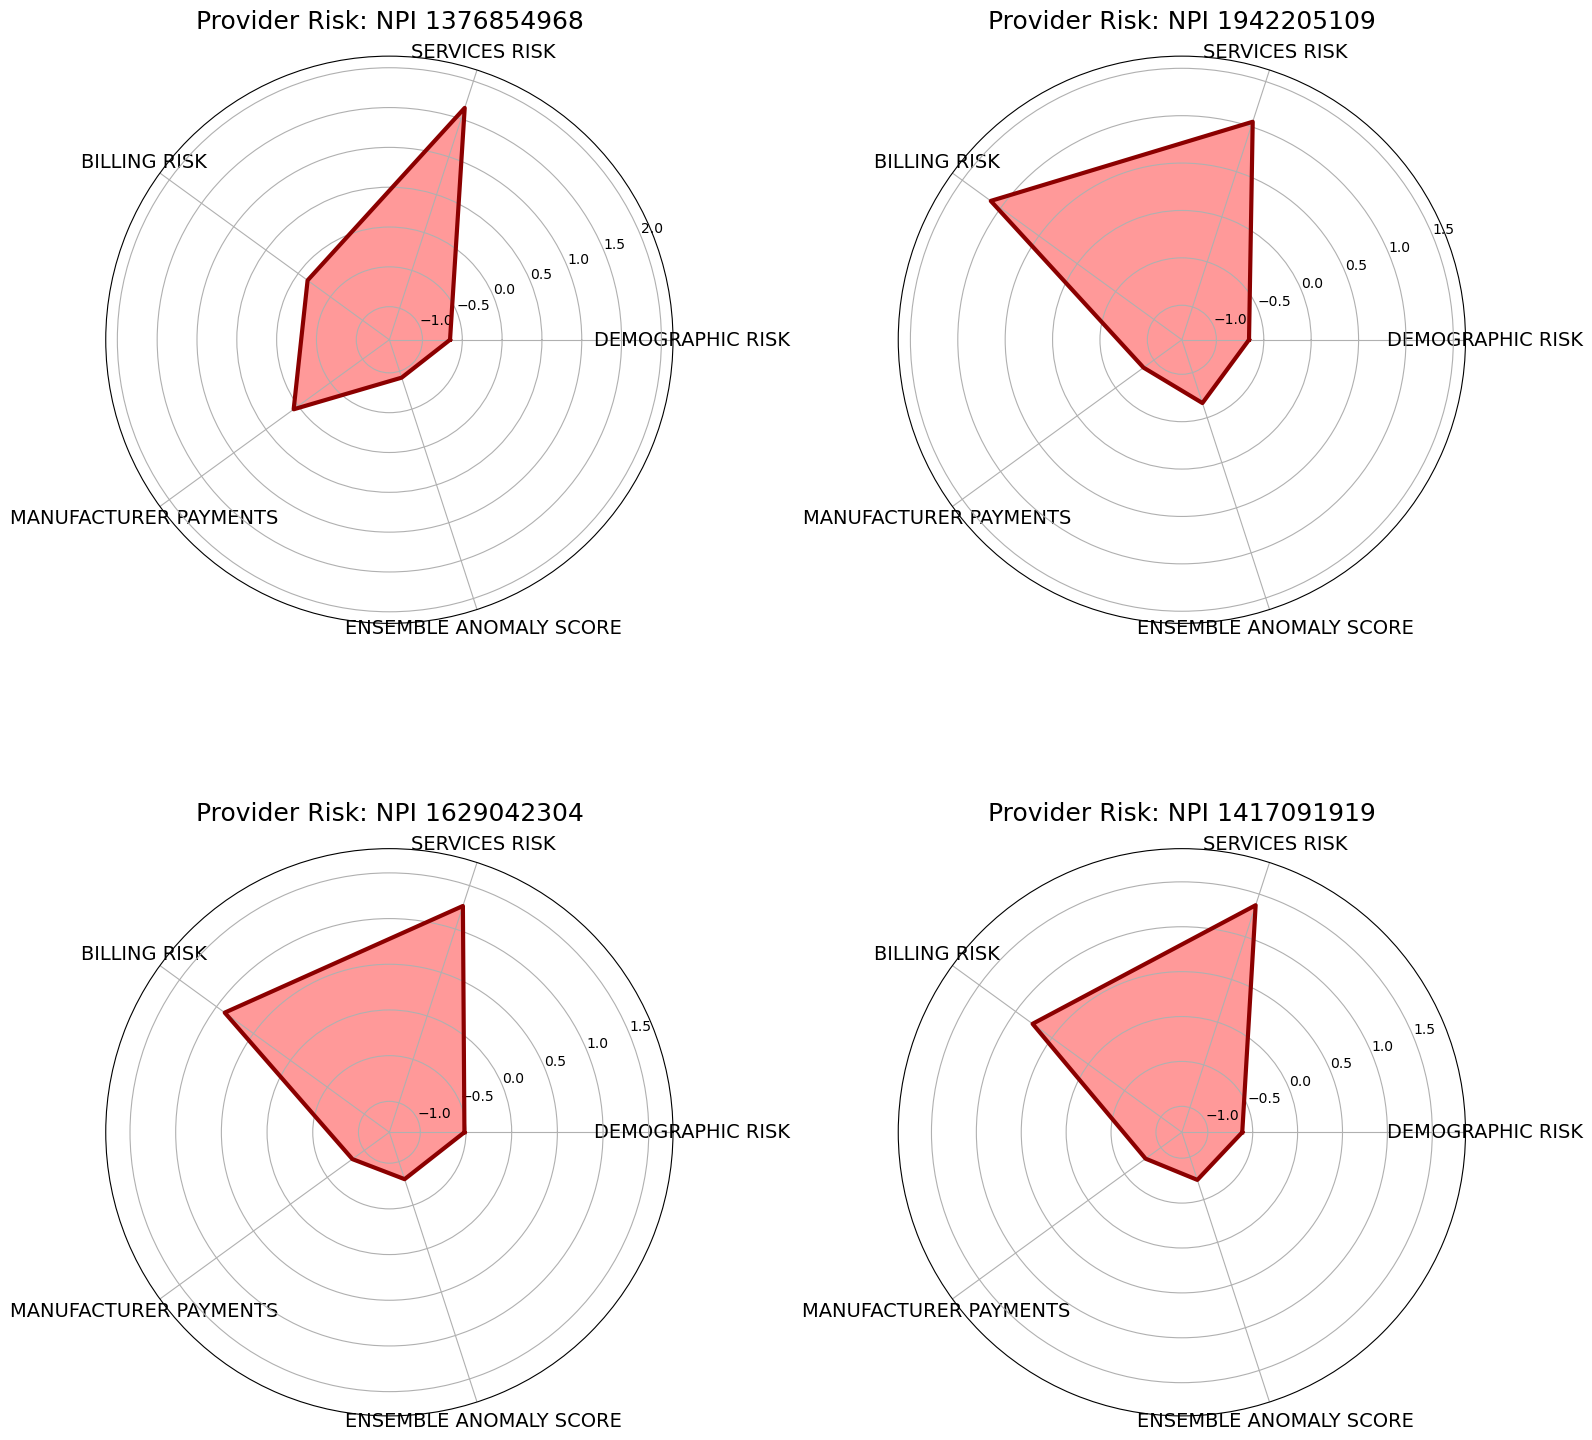

In [18]:
# Select fraudulent providers (randomized)
fraud_npies = unified_dataset[unified_dataset["fraud_flag"] == 1]["npi"].unique()  # Get all NPIs with fraud_flag
selected_npies = np.random.choice(fraud_npies, size = 4, replace = False)  # Pick four NPIs at random

# Create 2x2 grid with polar axes
fig, axes = plt.subplots(2, 2, figsize = (16, 16), subplot_kw = {"polar": True})  
axes = axes.flatten()  # Flatten axis array for easier iteration

# Loop through selected NPIs and plot radar for each
for idx, npi_value in enumerate(selected_npies):  # Loop through selected NPIs
    df_provider = unified_dataset[unified_dataset["npi"] == npi_value].fillna(0)  # Filter provider and replace nulls

    domain_scores = {}  # Initialize domain score storage

    for domain, cols in risk_factors.items():  # Loop through risk domains
        valid_cols = [c for c in cols if c in df_provider.columns]  # Identify usable columns
        if valid_cols:  # Check if columns are available
            domain_scores[domain] = df_provider[valid_cols].mean().mean()  # Compute domain score
        else:
            domain_scores[domain] = 0  # Assign default zero score

    score_df = pd.DataFrame({  # Create dataframe of domain scores
        "RiskFactor": domain_scores.keys(),
        "RawScore": domain_scores.values()
    })

    z_scores = (score_df["RawScore"] - score_df["RawScore"].mean()) / (score_df["RawScore"].std() + 1e-9) # Compute z scores
    score_df["ZScore"] = z_scores  # Store z scores

    angles = np.linspace(0, 2 * np.pi, len(score_df), endpoint = False) # Create angle positions
    angles = np.concatenate((angles, [angles[0]])) # Close radar loop

    values = np.concatenate((score_df["ZScore"].values, [score_df["ZScore"].values[0]])) 

    ax = axes[idx]  # Select axis for this provider

    # Plot radar
    ax.plot(angles, values, linewidth = 3, color = "darkred") 
    ax.fill(angles, values, alpha = 0.4, color = "red") 

    ax.set_xticks(angles[:-1])  # Set tick positions
    ax.set_xticklabels(score_df["RiskFactor"], fontsize = 14) 

    ax.set_ylim(values.min() - 0.5, values.max() + 0.5) # Set radius limits

    title_text = f"Provider Risk: NPI {npi_value}" # Create title text
    ax.set_title(title_text, fontsize = 18, pad = 20) # Set chart title

# display
plt.tight_layout() 
plt.show() 